### Deep learning model training.
#### Top accuracy(inner 512x512):
|model|miou|oa|date|     
|----|----|----|----|     
|deeplabv3+|0.912|0.948|20260428|    
|deeplabv3+(mb_v2)|0.923|0.962|20260428|  
||||    

#### Top accuracy(inner 448x448):
|model|miou|oa|date|     
|----|----|----|----|     
|deeplabv3+|0.888|0.924|20260428|    
|deeplabv3+(mb_v2)|0.904|0.943|20260428|  
||||    

### conclusions:   
1. 




In [1]:
import time
import torch
import random
import pandas as pd
import torch.nn as nn
from glob import glob
from notebooks import config
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils.imgShow import imsShow
from torchvision.transforms import v2
from utils.data_aug import GaussianNoise
from utils.dataloader import read_scenes 
from utils.metrics import oa_binary, miou_binary
from utils.dataloader import SceneArraySet, PatchPathSet
import segmentation_models_pytorch as smp
from model import u2net_timm
from model import deeplabv3plus, deeplabv3plus_mobilev2
from github_repo.SSRS.ASMFNet.models.swinfusenet.vision_transformer import SwinFuseNet
from model import CMFNet


In [2]:
patch_size = 448     ## patch size setting
patch_resize = None  ## patch resize setting
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
paths_dem_tra = config.paths_dem_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 52
vali patch 448: 208


### dataset loading

In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, 
                                     paths_truth_tra, 
                                     paths_dem_tra) 


In [4]:
transforms_tra = v2.Compose([
            v2.ToImage(),
            v2.RandomCrop(size=(patch_size, patch_size)),
            v2.RandomHorizontalFlip(p=0.3),
            v2.RandomVerticalFlip(p=0.3),
            v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),
            GaussianNoise(mean = 0.0, sigma_max_img=0.1, sigma_max_dem=0, p=0.3) 
            ])

transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])  


In [5]:
# Create dataset instances
tra_data = SceneArraySet(scenes_arr=scenes_arr, 
                          truths_arr=truths_arr, 
                          patch_size=patch_size,
                          transforms=transforms_tra)
val_data = PatchPathSet(paths_valset=paths_valset, transforms=transforms_val)

## Create data loaders
tra_loader = torch.utils.data.DataLoader(tra_data, 
                                         batch_size=4, 
                                         shuffle=True, 
                                         num_workers=5)
val_loader = torch.utils.data.DataLoader(val_data, 
                                         batch_size=4, 
                                         shuffle=False,
                                         num_workers=5)


#### Model training

In [6]:
model = deeplabv3plus(num_bands=7)
# model = deeplabv3plus_mobilev2(num_bands=7)
# model = smp.UnetPlusPlus("resnet34",  
#                   encoder_weights=None,  
#                   in_channels=7,  
#                   classes=1,  
#                   decoder_use_norm=True)
# model = smp.MAnet("resnet34",  
#                   encoder_weights=None,  
#                   in_channels=7,  
#                   classes=1,  
#                   decoder_use_norm=True)
# model = CMFNet(num_bands_b1=6, num_bands_b2=1, patch_size=512)
# model = SwinFuseNet(img_size=512, num_classes=1, num_bands_b1=6, num_bands_b2=1)


In [7]:
input_tensor = torch.randn(2, 7, 512, 512)  
output = model(input_tensor)  
output.shape  


torch.Size([2, 1, 512, 512])

In [8]:
### create loss and optimizer
# criterion = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()
# criterion = GlacierLoss(aux_weight=1)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
#                                           mode='min', 
#                                           factor=0.5, 
#                                           patience=30)


In [9]:
'''------train step------'''
def train_step(model, loss_fn, optimizer, x, y):
    optimizer.zero_grad()
    # pred, aux1, aux2, aux3  = model(x)
    # loss = loss_fn(pred, y, aux1, aux2, aux3)
    pred = model(x)
    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
    pred = (pred > 0.5).float()  ## convert prob to binary for metric calculation
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------validation step------'''
def val_step(model, loss_fn, x, y):
    with torch.no_grad():
        pred = model(x)
        # if x.shape[2] > 256:  ### crop inner 256x256 for evaluation
        #     pred = v2.functional.center_crop(pred, 256)
        #     y = v2.functional.center_crop(y, 256)
    loss = loss_fn(pred, y)
    pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
    pred = (pred > 0.5).float()  ## convert prob to binary
    miou = miou_binary(pred=pred, truth=y, device=x.device)
    oa = oa_binary(pred=pred, truth=y, device=x.device)
    return loss, miou, oa

'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,                     
                    epoches, 
                    device, 
                    lr_scheduler=None):
    tra_loss_loops, tra_miou_loops, tra_oa_loops = [], [], []
    val_loss_loops, val_miou_loops, val_oa_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    for epoch in range(epoches):
        start = time.time()
        tra_loss, val_loss = 0, 0
        tra_miou, val_miou = 0, 0
        tra_oa, val_oa = 0, 0
        '''-----train the model-----'''
        # model.train()   
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            loss, miou, oa = train_step(model=model, loss_fn=loss_fn, 
                                            optimizer=optimizer, 
                                            x=x_batch, 
                                            y=y_batch, 
                                            )
            tra_loss += loss.item()
            tra_miou += miou.item()
            tra_oa += oa.item()
        '''----- validation the model: time consuming -----'''
        model.eval()
        if (epoch+1) % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                loss, miou, oa = val_step(model=model, 
                                            loss_fn=loss_fn, 
                                            x=x_batch, 
                                            y=y_batch)
                val_loss += loss.item()
                val_miou += miou.item()
                val_oa += oa.item()
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            val_loss = val_loss/size_val_loader
            val_miou = val_miou/size_val_loader
            val_oa = val_oa/size_val_loader
            tra_loss_loops.append(tra_loss); tra_miou_loops.append(tra_miou); tra_oa_loops.append(tra_oa)
            val_loss_loops.append(val_loss); val_miou_loops.append(val_miou); val_oa_loops.append(val_oa)
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, '
                    f'val-> Loss:{val_loss:.3f},Oa:{val_oa:.3f}, Miou:{val_miou:.3f},time:{time.time()-start:.1f}s')
        else: 
            tra_loss = tra_loss/size_tra_loader
            tra_miou = tra_miou/size_tra_loader
            tra_oa = tra_oa/size_tra_loader
            print(f'Ep{epoch}: tra-> Loss:{tra_loss:.3f},Oa:{tra_oa:.3f},Miou:{tra_miou:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler:
          lr_scheduler.step(val_loss)    ## if using ReduceLROnPlateau
        ## show the result
        if (epoch+1)%20 == 0:            
            sam_index = random.randrange(len(val_data))
            patch, truth = val_data[sam_index]
            patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
            with torch.no_grad():
                pred = model(patch)
                pred = F.sigmoid(pred)  ## convert logit to prob for visualization
            if patch.shape[2] > 256:  ## zoom in for visualization if patch size > 256
                pred_val = v2.functional.center_crop(pred, 256)
                patch_val = v2.functional.center_crop(patch, 256)
                truth_val = v2.functional.center_crop(truth, 256)
            else:
                patch_val = patch
                pred_val = pred
                truth_val = truth
            ## convert to numpy and plot
            patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred = pred[0].to('cpu').detach().numpy()
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch, pred, patch_val, pred_val, truth_val], 
                    clip_list = (2,0,2,0,0),
                    img_name_list=['input_patch', 'pred', 'patch_zoom_in', 'pred_zoom_in', 'truth_zoom_in'], 
                    figsize=(15, 3))
            plt.tight_layout() 
    metrics = {'tra_loss':tra_loss_loops, 'tra_oa': tra_oa_loops, 'tra_miou': tra_miou_loops,
                'val_loss': val_loss_loops, 'val_oa': val_oa_loops, 'val_miou': val_miou_loops}
    return metrics 


Ep0: tra-> Loss:0.708,Oa:0.648,Miou:0.469,                                 time:3.7s
Ep1: tra-> Loss:0.797,Oa:0.399,Miou:0.338,                                 time:1.7s
Ep2: tra-> Loss:0.470,Oa:0.618,Miou:0.412, val-> Loss:0.330,Oa:0.654, Miou:0.442,time:3.6s
Ep3: tra-> Loss:0.179,Oa:0.881,Miou:0.785,                                 time:2.1s
Ep4: tra-> Loss:0.116,Oa:0.915,Miou:0.858,                                 time:2.0s
Ep5: tra-> Loss:0.131,Oa:0.916,Miou:0.876, val-> Loss:0.151,Oa:0.901, Miou:0.758,time:3.6s
Ep6: tra-> Loss:0.091,Oa:0.958,Miou:0.902,                                 time:1.7s
Ep7: tra-> Loss:0.084,Oa:0.955,Miou:0.903,                                 time:1.7s
Ep8: tra-> Loss:0.098,Oa:0.901,Miou:0.855, val-> Loss:0.193,Oa:0.880, Miou:0.806,time:3.6s
Ep9: tra-> Loss:0.123,Oa:0.905,Miou:0.854,                                 time:1.8s
Ep10: tra-> Loss:0.093,Oa:0.934,Miou:0.875,                                 time:1.8s
Ep11: tra-> Loss:0.094,Oa:0.952,Miou:0.912, va

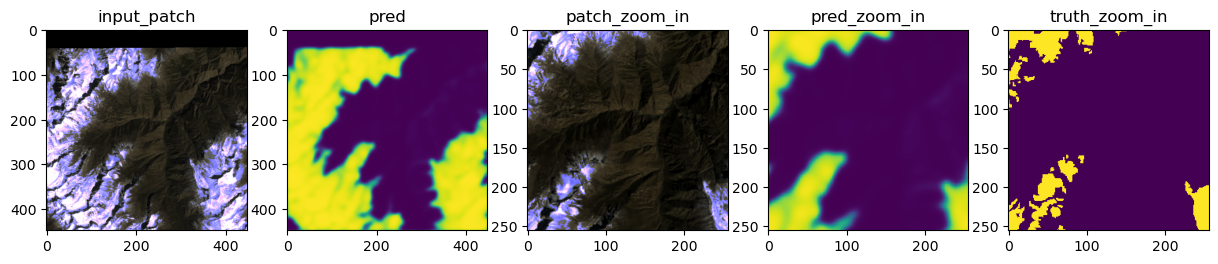

Ep20: tra-> Loss:0.096,Oa:0.916,Miou:0.867, val-> Loss:0.119,Oa:0.906, Miou:0.825,time:3.7s
Ep21: tra-> Loss:0.097,Oa:0.945,Miou:0.902,                                 time:1.8s
Ep22: tra-> Loss:0.096,Oa:0.952,Miou:0.898,                                 time:1.8s
Ep23: tra-> Loss:0.094,Oa:0.955,Miou:0.920, val-> Loss:0.114,Oa:0.904, Miou:0.830,time:3.7s
Ep24: tra-> Loss:0.079,Oa:0.936,Miou:0.905,                                 time:2.0s
Ep25: tra-> Loss:0.141,Oa:0.939,Miou:0.882,                                 time:1.8s
Ep26: tra-> Loss:0.098,Oa:0.934,Miou:0.888, val-> Loss:0.110,Oa:0.908, Miou:0.829,time:3.7s
Ep27: tra-> Loss:0.084,Oa:0.926,Miou:0.883,                                 time:1.7s
Ep28: tra-> Loss:0.070,Oa:0.931,Miou:0.906,                                 time:1.9s
Ep29: tra-> Loss:0.060,Oa:0.950,Miou:0.911, val-> Loss:0.118,Oa:0.899, Miou:0.835,time:3.8s
Ep30: tra-> Loss:0.093,Oa:0.934,Miou:0.878,                                 time:2.1s
Ep31: tra-> Loss:0.107,Oa:0.94

<Figure size 640x480 with 0 Axes>

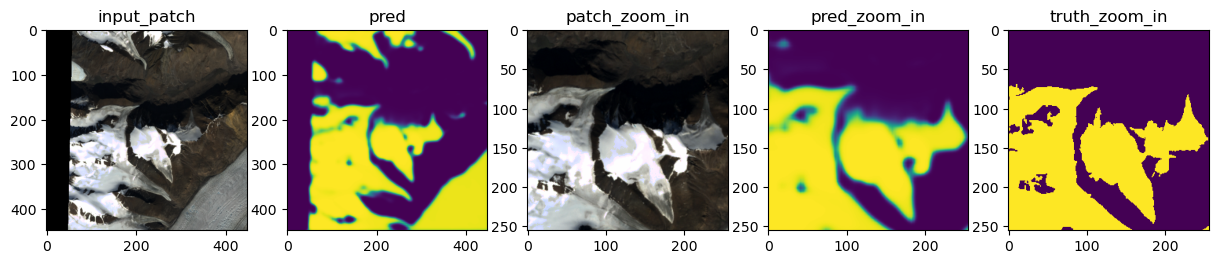

Ep40: tra-> Loss:0.083,Oa:0.914,Miou:0.872,                                 time:1.9s
Ep41: tra-> Loss:0.096,Oa:0.926,Miou:0.882, val-> Loss:0.116,Oa:0.896, Miou:0.840,time:3.8s
Ep42: tra-> Loss:0.077,Oa:0.961,Miou:0.904,                                 time:1.9s
Ep43: tra-> Loss:0.075,Oa:0.958,Miou:0.923,                                 time:1.8s
Ep44: tra-> Loss:0.079,Oa:0.951,Miou:0.915, val-> Loss:0.088,Oa:0.916, Miou:0.841,time:3.7s
Ep45: tra-> Loss:0.114,Oa:0.947,Miou:0.860,                                 time:1.7s
Ep46: tra-> Loss:0.106,Oa:0.934,Miou:0.902,                                 time:1.9s
Ep47: tra-> Loss:0.099,Oa:0.953,Miou:0.904, val-> Loss:0.094,Oa:0.911, Miou:0.838,time:3.7s
Ep48: tra-> Loss:0.068,Oa:0.948,Miou:0.905,                                 time:2.7s
Ep49: tra-> Loss:0.078,Oa:0.909,Miou:0.874,                                 time:1.7s
Ep50: tra-> Loss:0.123,Oa:0.916,Miou:0.838, val-> Loss:0.126,Oa:0.935, Miou:0.826,time:3.8s
Ep51: tra-> Loss:0.111,Oa:0.92

<Figure size 640x480 with 0 Axes>

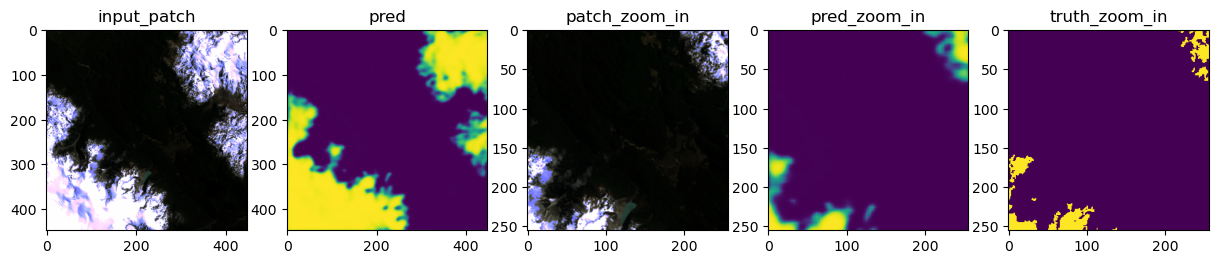

Ep60: tra-> Loss:0.065,Oa:0.942,Miou:0.888,                                 time:2.1s
Ep61: tra-> Loss:0.102,Oa:0.908,Miou:0.865,                                 time:1.7s
Ep62: tra-> Loss:0.122,Oa:0.927,Miou:0.848, val-> Loss:0.096,Oa:0.881, Miou:0.838,time:3.8s
Ep63: tra-> Loss:0.111,Oa:0.915,Miou:0.873,                                 time:1.9s
Ep64: tra-> Loss:0.078,Oa:0.957,Miou:0.910,                                 time:1.8s
Ep65: tra-> Loss:0.100,Oa:0.942,Miou:0.900, val-> Loss:0.084,Oa:0.910, Miou:0.849,time:3.9s
Ep66: tra-> Loss:0.068,Oa:0.964,Miou:0.913,                                 time:1.8s
Ep67: tra-> Loss:0.073,Oa:0.952,Miou:0.920,                                 time:1.8s
Ep68: tra-> Loss:0.071,Oa:0.957,Miou:0.920, val-> Loss:0.077,Oa:0.914, Miou:0.854,time:3.9s
Ep69: tra-> Loss:0.077,Oa:0.950,Miou:0.919,                                 time:1.6s
Ep70: tra-> Loss:0.071,Oa:0.915,Miou:0.864,                                 time:1.6s
Ep71: tra-> Loss:0.081,Oa:0.929,Miou

<Figure size 640x480 with 0 Axes>

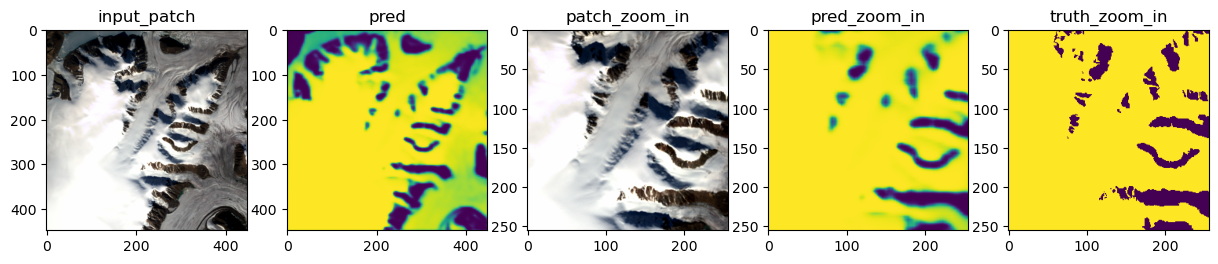

Ep80: tra-> Loss:0.064,Oa:0.959,Miou:0.925, val-> Loss:0.068,Oa:0.918, Miou:0.866,time:3.8s
Ep81: tra-> Loss:0.072,Oa:0.964,Miou:0.912,                                 time:2.0s
Ep82: tra-> Loss:0.070,Oa:0.952,Miou:0.922,                                 time:2.0s
Ep83: tra-> Loss:0.067,Oa:0.945,Miou:0.902, val-> Loss:0.068,Oa:0.929, Miou:0.878,time:3.8s
Ep84: tra-> Loss:0.077,Oa:0.955,Miou:0.927,                                 time:2.0s
Ep85: tra-> Loss:0.097,Oa:0.956,Miou:0.900,                                 time:1.7s
Ep86: tra-> Loss:0.078,Oa:0.937,Miou:0.911, val-> Loss:0.069,Oa:0.926, Miou:0.878,time:3.9s
Ep87: tra-> Loss:0.054,Oa:0.948,Miou:0.912,                                 time:2.1s
Ep88: tra-> Loss:0.061,Oa:0.950,Miou:0.916,                                 time:1.9s
Ep89: tra-> Loss:0.055,Oa:0.975,Miou:0.952, val-> Loss:0.089,Oa:0.901, Miou:0.858,time:4.0s
Ep90: tra-> Loss:0.063,Oa:0.958,Miou:0.906,                                 time:2.5s
Ep91: tra-> Loss:0.065,Oa:0.96

<Figure size 640x480 with 0 Axes>

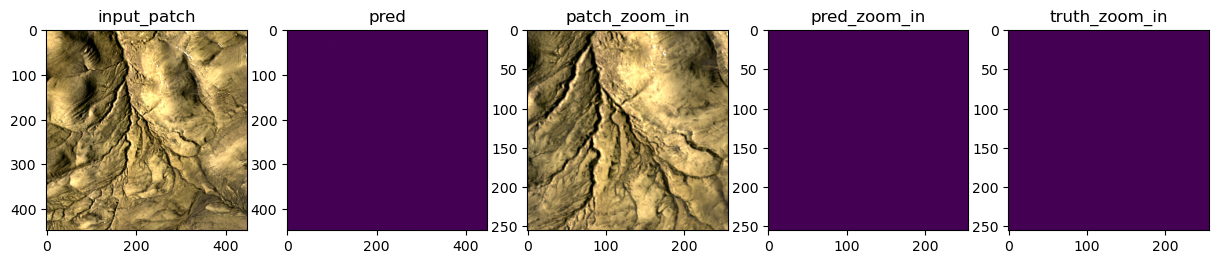

Ep100: tra-> Loss:0.050,Oa:0.923,Miou:0.869,                                 time:1.8s
Ep101: tra-> Loss:0.049,Oa:0.944,Miou:0.911, val-> Loss:0.063,Oa:0.925, Miou:0.878,time:3.9s
Ep102: tra-> Loss:0.050,Oa:0.966,Miou:0.936,                                 time:1.9s
Ep103: tra-> Loss:0.097,Oa:0.954,Miou:0.805,                                 time:1.8s
Ep104: tra-> Loss:0.075,Oa:0.909,Miou:0.847, val-> Loss:0.084,Oa:0.905, Miou:0.856,time:4.0s
Ep105: tra-> Loss:0.062,Oa:0.963,Miou:0.935,                                 time:2.1s
Ep106: tra-> Loss:0.060,Oa:0.973,Miou:0.896,                                 time:1.8s
Ep107: tra-> Loss:0.055,Oa:0.934,Miou:0.904, val-> Loss:0.070,Oa:0.907, Miou:0.860,time:3.8s
Ep108: tra-> Loss:0.052,Oa:0.960,Miou:0.928,                                 time:1.8s
Ep109: tra-> Loss:0.062,Oa:0.929,Miou:0.888,                                 time:1.9s
Ep110: tra-> Loss:0.063,Oa:0.962,Miou:0.923, val-> Loss:0.076,Oa:0.902, Miou:0.860,time:3.8s
Ep111: tra-> Loss:0

<Figure size 640x480 with 0 Axes>

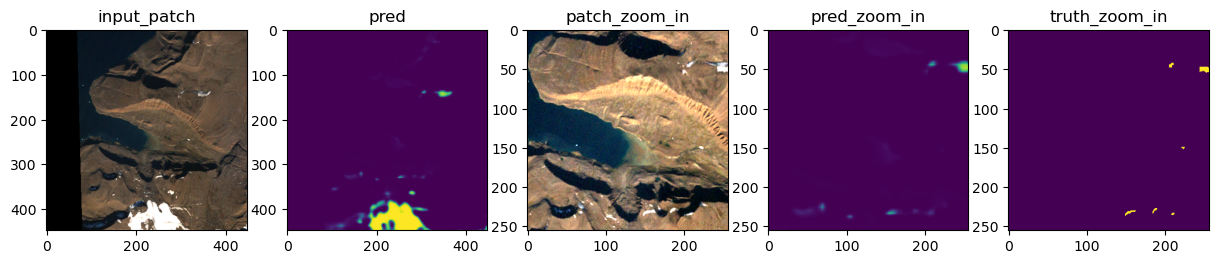

Ep120: tra-> Loss:0.183,Oa:0.911,Miou:0.831,                                 time:1.8s
Ep121: tra-> Loss:0.115,Oa:0.931,Miou:0.872,                                 time:2.9s
Ep122: tra-> Loss:0.098,Oa:0.909,Miou:0.867, val-> Loss:0.083,Oa:0.912, Miou:0.853,time:3.8s
Ep123: tra-> Loss:0.072,Oa:0.914,Miou:0.881,                                 time:1.9s
Ep124: tra-> Loss:0.065,Oa:0.952,Miou:0.927,                                 time:1.7s
Ep125: tra-> Loss:0.071,Oa:0.953,Miou:0.921, val-> Loss:0.070,Oa:0.917, Miou:0.859,time:3.9s
Ep126: tra-> Loss:0.067,Oa:0.940,Miou:0.889,                                 time:2.0s
Ep127: tra-> Loss:0.051,Oa:0.966,Miou:0.936,                                 time:1.9s
Ep128: tra-> Loss:0.052,Oa:0.969,Miou:0.939, val-> Loss:0.062,Oa:0.926, Miou:0.884,time:3.9s
Ep129: tra-> Loss:0.058,Oa:0.954,Miou:0.921,                                 time:1.7s
Ep130: tra-> Loss:0.041,Oa:0.973,Miou:0.943,                                 time:1.7s
Ep131: tra-> Loss:0.054,O

<Figure size 640x480 with 0 Axes>

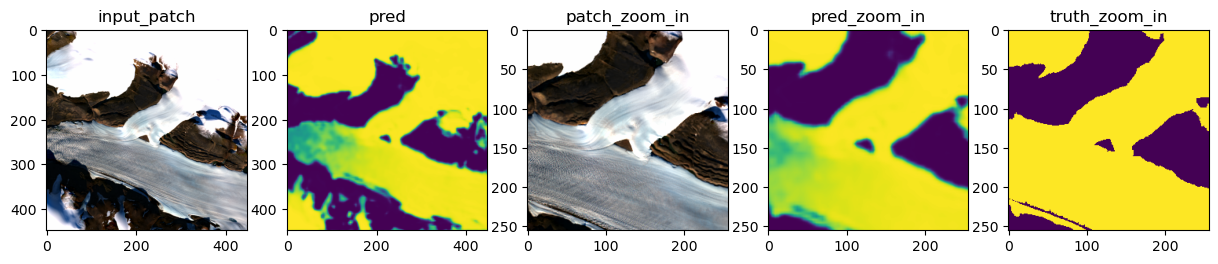

Ep140: tra-> Loss:0.058,Oa:0.949,Miou:0.917, val-> Loss:0.064,Oa:0.931, Miou:0.875,time:3.7s
Ep141: tra-> Loss:0.049,Oa:0.960,Miou:0.918,                                 time:1.9s
Ep142: tra-> Loss:0.054,Oa:0.954,Miou:0.920,                                 time:1.9s
Ep143: tra-> Loss:0.043,Oa:0.948,Miou:0.913, val-> Loss:0.063,Oa:0.926, Miou:0.886,time:4.2s
Ep144: tra-> Loss:0.069,Oa:0.968,Miou:0.939,                                 time:2.8s
Ep145: tra-> Loss:0.086,Oa:0.928,Miou:0.892,                                 time:2.1s
Ep146: tra-> Loss:0.123,Oa:0.934,Miou:0.896, val-> Loss:0.105,Oa:0.907, Miou:0.860,time:4.9s
Ep147: tra-> Loss:0.077,Oa:0.894,Miou:0.859,                                 time:1.7s
Ep148: tra-> Loss:0.062,Oa:0.983,Miou:0.962,                                 time:2.1s
Ep149: tra-> Loss:0.043,Oa:0.970,Miou:0.946, val-> Loss:0.071,Oa:0.927, Miou:0.868,time:3.7s
Ep150: tra-> Loss:0.065,Oa:0.957,Miou:0.887,                                 time:1.7s
Ep151: tra-> Loss:0

<Figure size 640x480 with 0 Axes>

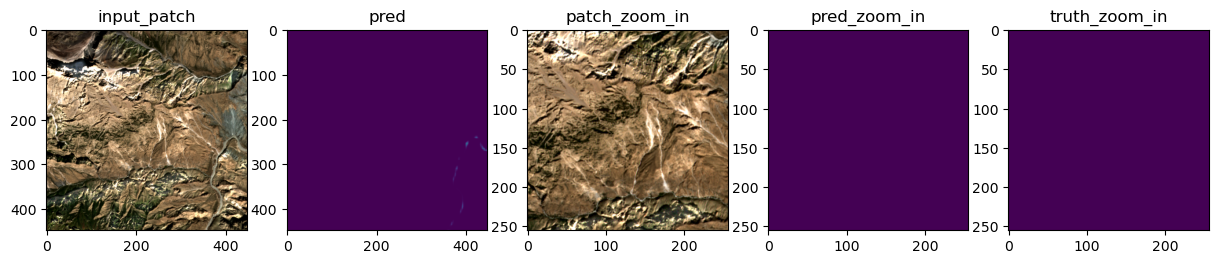

Ep160: tra-> Loss:0.065,Oa:0.957,Miou:0.920,                                 time:1.9s
Ep161: tra-> Loss:0.066,Oa:0.968,Miou:0.913, val-> Loss:0.071,Oa:0.912, Miou:0.880,time:3.8s
Ep162: tra-> Loss:0.061,Oa:0.942,Miou:0.906,                                 time:2.2s
Ep163: tra-> Loss:0.052,Oa:0.966,Miou:0.940,                                 time:1.8s
Ep164: tra-> Loss:0.058,Oa:0.888,Miou:0.849, val-> Loss:0.059,Oa:0.944, Miou:0.879,time:4.0s
Ep165: tra-> Loss:0.051,Oa:0.959,Miou:0.924,                                 time:1.9s
Ep166: tra-> Loss:0.046,Oa:0.911,Miou:0.850,                                 time:1.8s
Ep167: tra-> Loss:0.051,Oa:0.965,Miou:0.872, val-> Loss:0.065,Oa:0.935, Miou:0.869,time:3.7s
Ep168: tra-> Loss:0.069,Oa:0.954,Miou:0.913,                                 time:1.7s
Ep169: tra-> Loss:0.045,Oa:0.968,Miou:0.928,                                 time:1.7s
Ep170: tra-> Loss:0.056,Oa:0.956,Miou:0.903, val-> Loss:0.060,Oa:0.924, Miou:0.888,time:4.2s
Ep171: tra-> Loss:0

<Figure size 640x480 with 0 Axes>

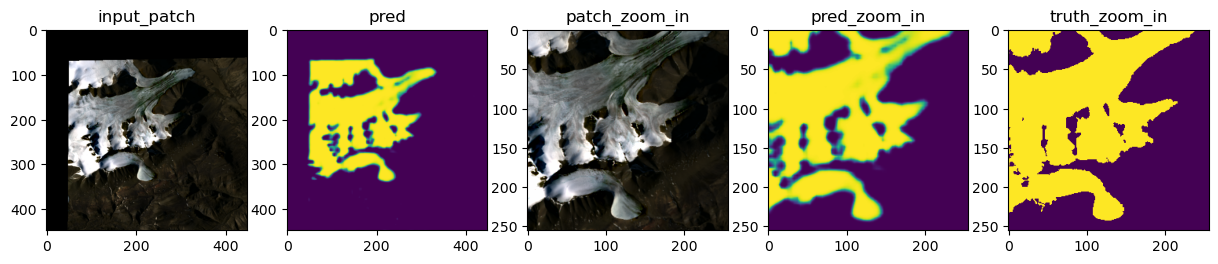

Ep180: tra-> Loss:0.045,Oa:0.952,Miou:0.912,                                 time:1.9s
Ep181: tra-> Loss:0.037,Oa:0.953,Miou:0.928,                                 time:1.7s
Ep182: tra-> Loss:0.038,Oa:0.956,Miou:0.901, val-> Loss:0.060,Oa:0.924, Miou:0.887,time:3.8s
Ep183: tra-> Loss:0.051,Oa:0.964,Miou:0.935,                                 time:1.9s
Ep184: tra-> Loss:0.043,Oa:0.977,Miou:0.950,                                 time:1.9s
Ep185: tra-> Loss:0.040,Oa:0.938,Miou:0.917, val-> Loss:0.059,Oa:0.929, Miou:0.875,time:3.7s
Ep186: tra-> Loss:0.040,Oa:0.902,Miou:0.845,                                 time:2.0s
Ep187: tra-> Loss:0.040,Oa:0.982,Miou:0.965,                                 time:1.8s
Ep188: tra-> Loss:0.045,Oa:0.941,Miou:0.895, val-> Loss:0.060,Oa:0.920, Miou:0.881,time:3.8s
Ep189: tra-> Loss:0.037,Oa:0.975,Miou:0.943,                                 time:1.8s
Ep190: tra-> Loss:0.049,Oa:0.943,Miou:0.912,                                 time:1.8s
Ep191: tra-> Loss:0.048,O

<Figure size 640x480 with 0 Axes>

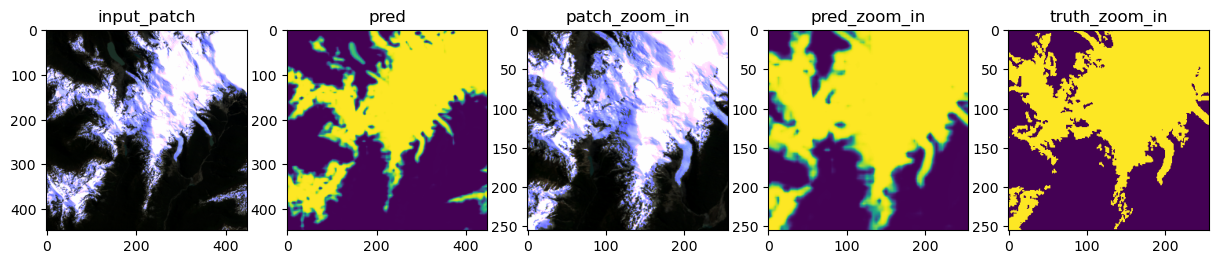

<Figure size 640x480 with 0 Axes>

In [10]:
device = torch.device('cuda:1') 
metrics = train_loops(model=model, 
                epoches=200,  
                loss_fn=criterion,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  


In [11]:
# # model saving 
# # model_name = 'unet' 
# # model_name = 'unet_att' 
# model_name = 'u2net_cbam' 
# # model_name = 'deeplabv3plus'  
# # model_name = 'deeplabv3plus_mb2' 
# date_str = time.strftime("%Y-%m-%d-%H", time.localtime())
# date_str = date_str.replace('-', '')  ## remove '-' for file name
# # path_save = f'model/trained/{model_name}/{model_name}_weights_1.pth'
# path_save = f'model/trained/seg_models/{model_name}_weights_{date_str}.pth'
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# ## model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# ## metrics saving
# path_metrics = f'model/trained/seg_models/{model_name}_metrics_{date_str}.csv'    
# ## path_metrics = f'model/trained/{model_name}/{model_name}_metrics_1.csv'    
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')
